In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [12]:
df=pd.read_csv("https://raw.githubusercontent.com/srivatsan88/YouTubeLI/master/dataset/electricity_consumption.csv")
df['Bill_Date']=pd.to_datetime(df['Bill_Date'])
df.head()

,Bill_Date,On_peak,Off_peak,Usage_charge,Billed_amount,Billing_days
0,2016-01-01,365,1423.5,219.0,247.73,31
1,2016-02-01,292,1138.8,175.2,234.11,31
2,2016-03-01,130,507.0,78.0,123.85,29
3,2016-04-01,117,456.3,70.2,111.22,29
4,2016-05-01,136,530.4,81.6,118.37,29


In [13]:
df.set_index("Bill_Date",inplace=True,drop=True)
df.head()

,On_peak,Off_peak,Usage_charge,Billed_amount,Billing_days
Bill_Date,,,,,
2016-01-01,365,1423.5,219.0,247.73,31
2016-02-01,292,1138.8,175.2,234.11,31
2016-03-01,130,507.0,78.0,123.85,29
2016-04-01,117,456.3,70.2,111.22,29
2016-05-01,136,530.4,81.6,118.37,29


# simple moving average

In [14]:
df=df[['Billed_amount']]
df=df.loc['2016':'2018',:]
df.head()

,Billed_amount
Bill_Date,
2016-01-01,247.73
2016-02-01,234.11
2016-03-01,123.85
2016-04-01,111.22
2016-05-01,118.37


In [17]:
df['Billed_amount_mA']=df['Billed_amount'].rolling(window=3).mean().shift(1)

In [18]:
df.head()

,Billed_amount,Billed_amount_mA
Bill_Date,,
2016-01-01,247.73,NaN
2016-02-01,234.11,NaN
2016-03-01,123.85,NaN
2016-04-01,111.22,201.896667
2016-05-01,118.37,156.393333


<Axes: xlabel='Bill_Date'>

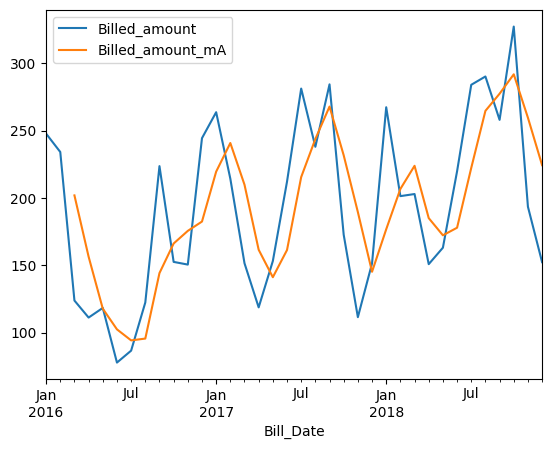

In [16]:
df.plot()

# Weighted moving average

In [21]:
df['Billed_amount_WMA']=((df['Billed_amount']*1.5+df['Billed_amount'].shift(1)*1+df['Billed_amount'].shift(2)*0.5)/3).shift(1)

<Axes: xlabel='Bill_Date'>

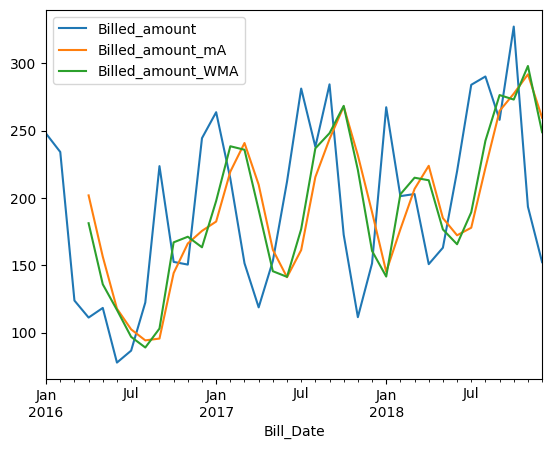

In [22]:
df.plot()

# Exponential moving average

## EMAt​=α⋅xt​+(1−α)⋅EMAt−1​

α=2/(N+1)  where N is window size

In [27]:
df['Billed_amount_EMA']=df['Billed_amount'].ewm(span=3).mean().shift(1)

<Axes: xlabel='Bill_Date'>

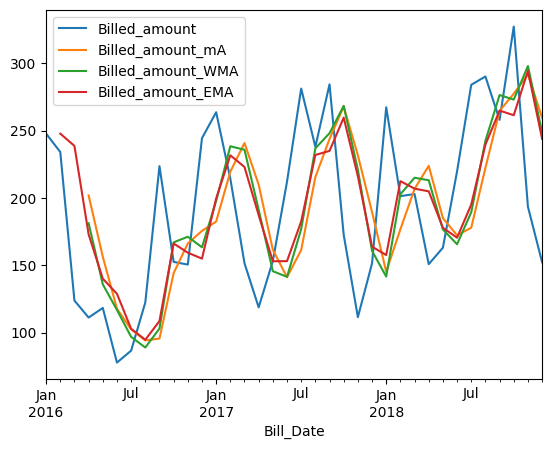

In [28]:
df.plot()

# Exponential smothing
<img src="https://i.ibb.co/0VY79BnP/image.png">

In [30]:
df['exp_smothing']=df['Billed_amount'].ewm(alpha=0.7).mean().shift(1)

<Axes: xlabel='Bill_Date'>

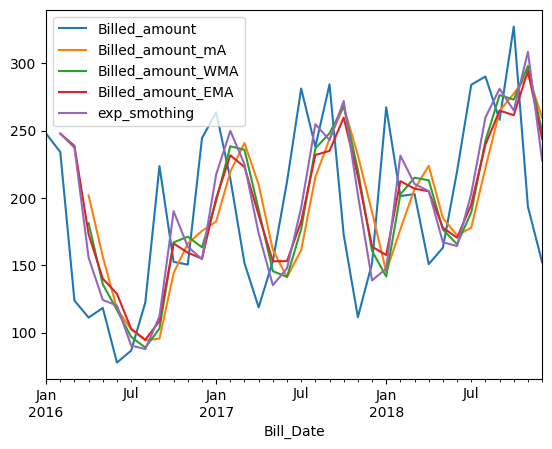

In [31]:
df.plot()